In [2]:
experiment = "vggnet16_benchmark2022_segmented_one_img"

import pandas as pd
CSV_PATH = f"../results/{experiment}/combined_results.csv"
df = pd.read_csv(CSV_PATH)

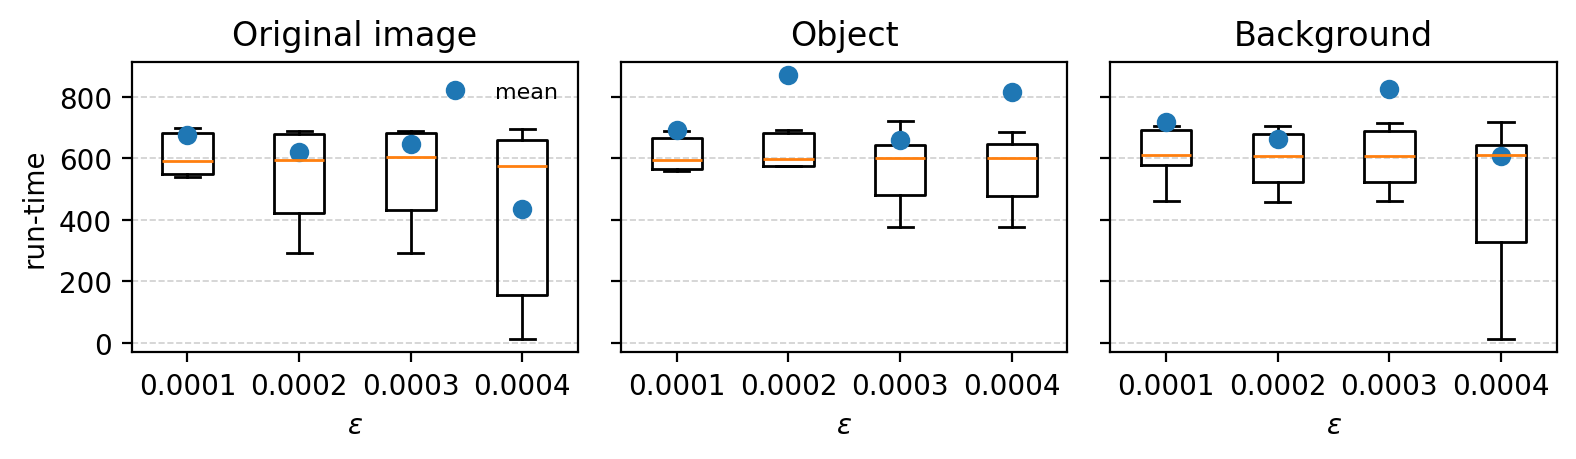

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)

    keep = pd.Series(True, index=frame.index)
    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def prep_data(sub: pd.DataFrame):
    sub = sub.copy()
    sub[TIME_COL] = pd.to_numeric(sub[TIME_COL], errors="coerce")
    sub = sub.dropna(subset=["eps", TIME_COL]).copy()

    eps_vals = sorted(sub["eps"].unique())
    data_per_eps = [sub.loc[sub["eps"] == eps, TIME_COL].values for eps in eps_vals]

    return eps_vals, data_per_eps

def boxplot_on_ax(ax, data_per_eps, eps_vals, title, show_legend=False):
    ax.boxplot(
        data_per_eps,
        tick_labels=[f"{e:g}" for e in eps_vals],
        showfliers=False,
        widths=0.45,   # thinner boxes
    )

    means = [np.mean(v) if len(v) else np.nan for v in data_per_eps]
    ax.plot(
        range(1, len(eps_vals) + 1),
        means,
        marker="o",
        linestyle="none",
        label="mean",
    )

    ax.set_xlabel(r"$\epsilon$")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    if show_legend:
        ax.legend(frameon=False, fontsize=8)

# ---------------------------
# Build subsets
# ---------------------------

# Original image (global)
if "is_global" in df.columns:
    df_orig = df[df["is_global"] == True].copy()
else:
    df_orig = filter_by_tag_contains(df, include_any=("global",))

# Object (segmented mask)
df_object = filter_by_tag_contains(
    df,
    include_all=("seg", "mask"),
    exclude_any=("non-mask", "nonmask", "non_mask"),
)

# Background (segmented non-mask)
df_background = filter_by_tag_contains(
    df,
    include_all=("seg",),
    include_any=("non-mask", "nonmask", "non_mask"),
)

# ---------------------------
# Prepare data
# ---------------------------
orig_eps, orig_data = prep_data(df_orig)
obj_eps, obj_data = prep_data(df_object)
bg_eps, bg_data = prep_data(df_background)

# ---------------------------
# Plot: 3 side-by-side figures
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.4), dpi=200, sharey=True)

axes[0].set_ylabel("run-time")

boxplot_on_ax(
    axes[0],
    orig_data,
    orig_eps,
    "Original image",
    show_legend=True,
)

boxplot_on_ax(
    axes[1],
    obj_data,
    obj_eps,
    "Object",
)

boxplot_on_ax(
    axes[2],
    bg_data,
    bg_eps,
    "Background",
)

plt.tight_layout();
plt.show();

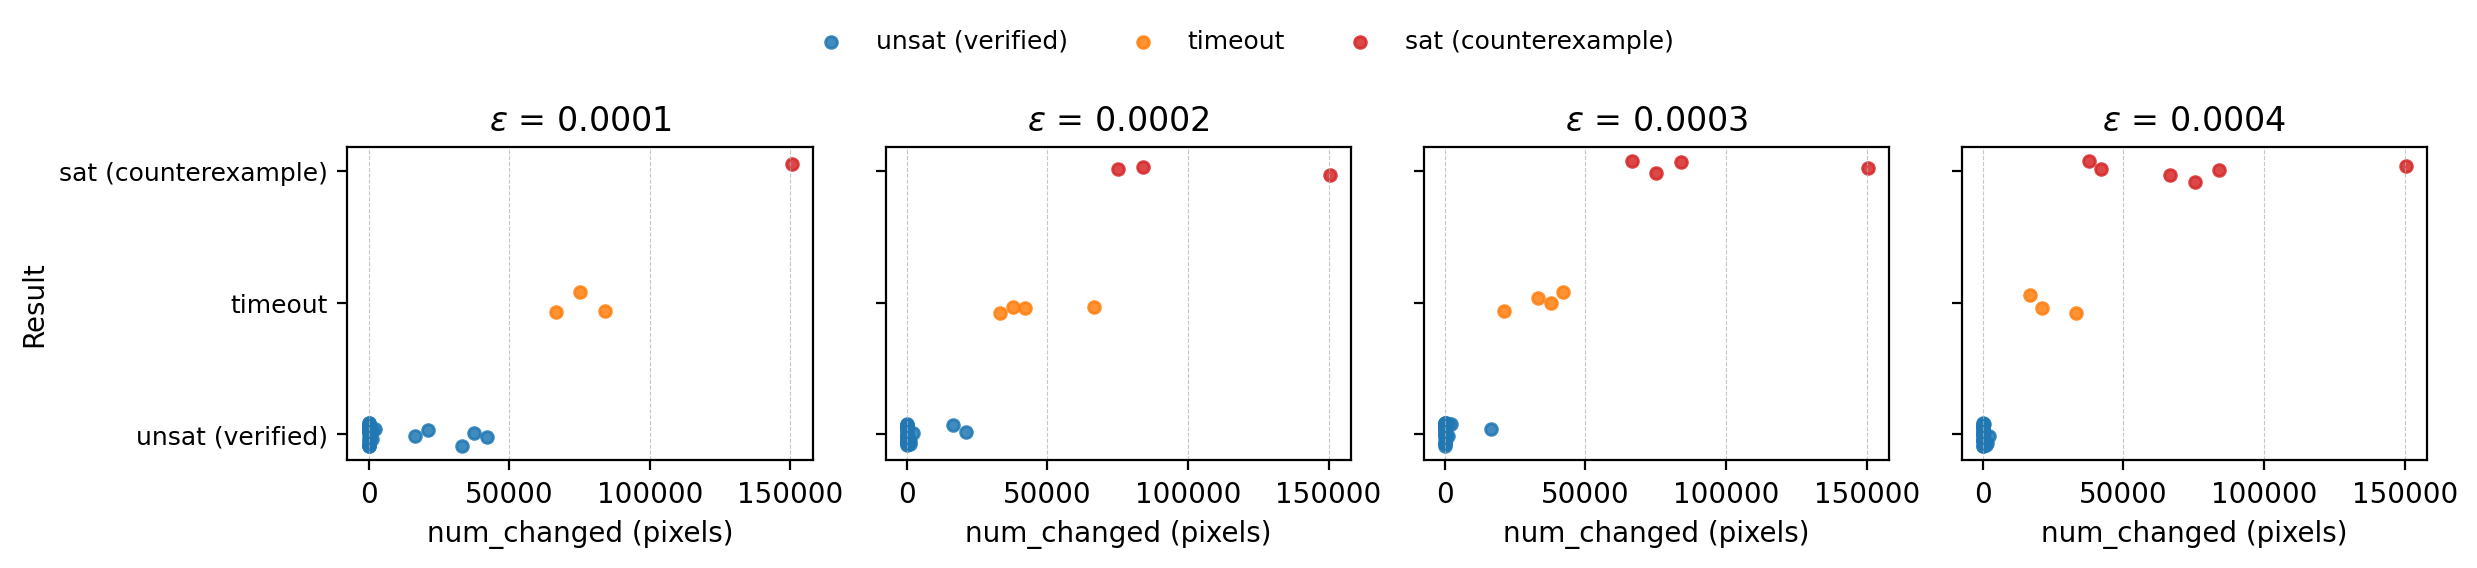

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_COL = "num_changed"   # <-- number of changed pixels
EPS_COL = "eps"
RES_COL = "result"

# ---------------------------------------
# 1) Map "result" column -> y categories
# ---------------------------------------
def map_result(r):
    if pd.isna(r):
        return "other"
    r = str(r).strip().lower()

    if r == "unsat false":
        return "unsat (verified)"
    if r == "sat true":
        return "sat (counterexample)"
    if r == "timeout false":
        return "timeout"
    return "other"

ORDER = [
    "unsat (verified)",
    "timeout",
    "sat (counterexample)",
    "other",
]

COLOR_MAP = {
    "unsat (verified)":     "#1f77b4",
    "timeout":              "#ff7f0e",
    "sat (counterexample)": "#d62728",
    "other":                "#7f7f7f",
}

# ---------------------------------------
# 2) Prep data
# ---------------------------------------
d = df.copy()
d[EPS_COL] = pd.to_numeric(d[EPS_COL], errors="coerce")
d[X_COL] = pd.to_numeric(d[X_COL], errors="coerce")

# Keep rows that have eps and num_changed
d = d.dropna(subset=[EPS_COL, X_COL]).copy()

# Map result categories ONLY from result column
d["y_cat"] = d[RES_COL].apply(map_result)

# Keep only categories that exist, but in fixed order
present = [c for c in ORDER if c in set(d["y_cat"].unique())]

# Numeric y positions for jitter
y_to_num = {c: i for i, c in enumerate(present)}
d["y_num"] = d["y_cat"].map(y_to_num)

# ---------------------------------------
# 3) 4 panels next to each other (one per eps)
# ---------------------------------------
eps_list = sorted(d[EPS_COL].dropna().unique())[:4]
fig, axes = plt.subplots(1, len(eps_list), figsize=(12.5, 2.8), dpi=200, sharey=True)
if len(eps_list) == 1:
    axes = [axes]

rng = np.random.default_rng(0)

for ax, eps in zip(axes, eps_list):
    sub = d[d[EPS_COL] == eps].copy()
    if sub.empty:
        ax.set_title(rf"$\epsilon$={eps:g}" + "\n(no data)")
        ax.axis("off")
        continue

    # Jitter the y positions a bit
    y_num = sub["y_num"].astype(float).to_numpy()
    y_jitter = y_num + (rng.random(len(y_num)) - 0.5) * 0.18

    x = sub[X_COL].to_numpy()

    for cat in present:
        mask = (sub["y_cat"] == cat).to_numpy()
        if not mask.any():
            continue
        ax.scatter(
            x[mask], y_jitter[mask],
            s=18, alpha=0.85,
            color=COLOR_MAP.get(cat, "#7f7f7f"),
            label=cat
        )

    ax.set_title(rf"$\epsilon$ = {eps:g}", fontsize=12)
    ax.set_xlabel("num_changed (pixels)")
    # If your num_changed spans a huge range (e.g., 2..5000), uncomment:
    # ax.set_xscale("log")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.7)

# y-axis labels = results
axes[0].set_ylabel("Result")
axes[0].set_yticks(range(len(present)))
axes[0].set_yticklabels(present, fontsize=9)

# One legend for the whole figure (deduplicate)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc="upper center",
    ncol=min(6, len(by_label)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

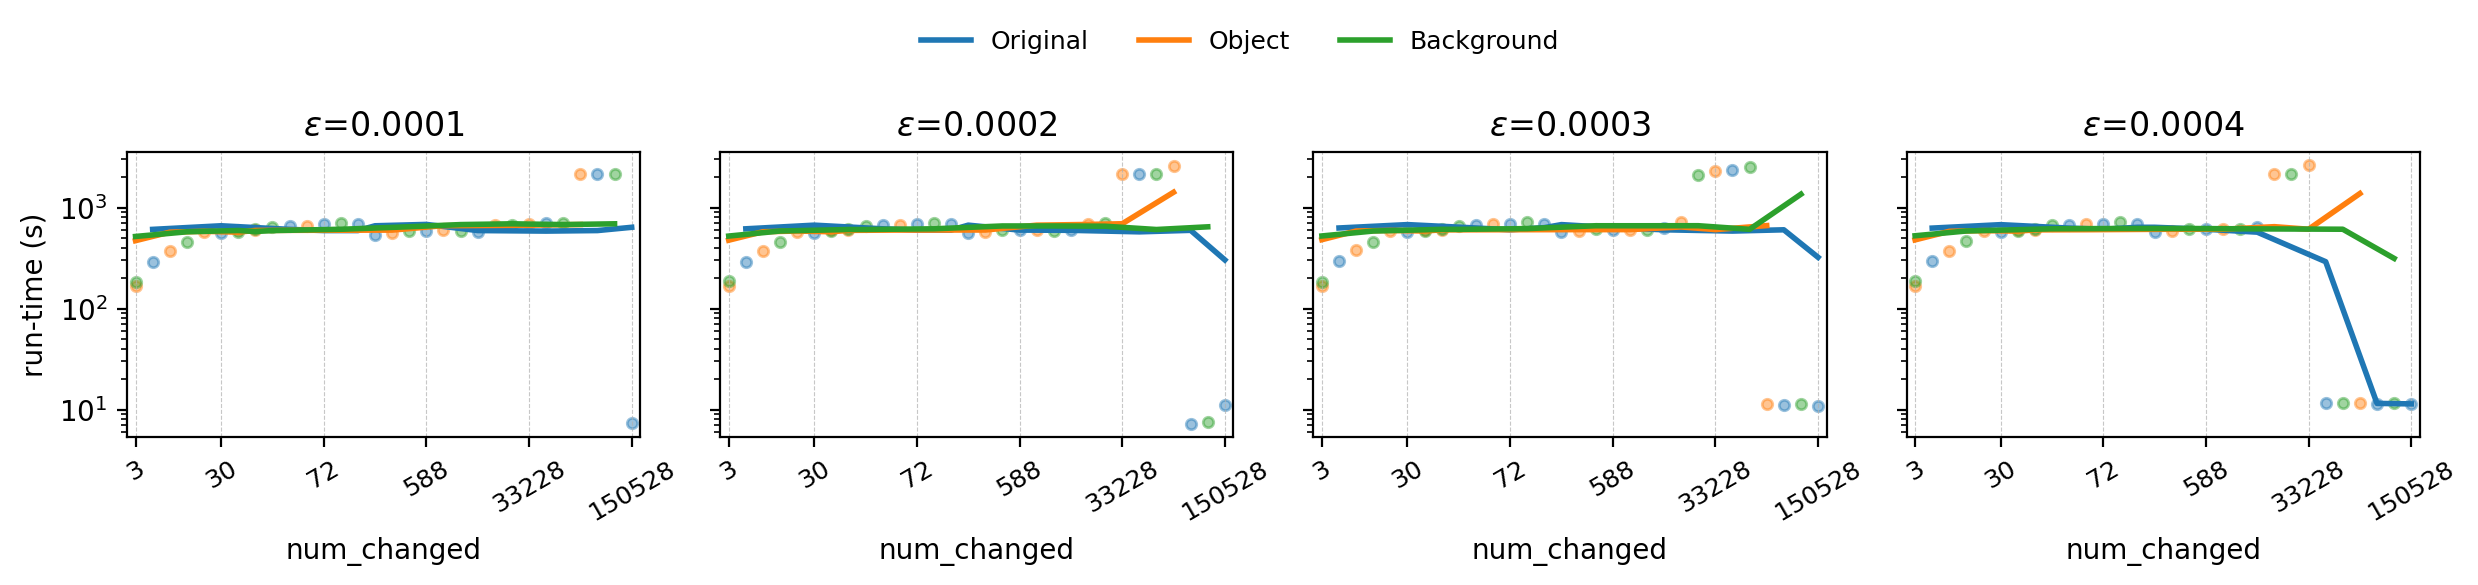

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"
X_COL = "num_changed"

ROLLING_WINDOW = 7
SMOOTH_METHOD = "median"
MIN_POINTS = 3

# -----------------------------
# Mode classifier
# -----------------------------
def infer_mode(row):
    tag = str(row.get("tag", "")).lower()
    is_global = row.get("is_global", None)

    if is_global is True or ("global" in tag) or ("original" in tag):
        return "Original"
    if ("non-mask" in tag) or ("nonmask" in tag) or ("non_mask" in tag):
        return "Background"
    if ("mask" in tag) and not (("non-mask" in tag) or ("nonmask" in tag) or ("non_mask" in tag)):
        return "Object"
    return "Other"

MODE_ORDER = ["Original", "Object", "Background"]
MODE_COLOR = {
    "Original": "#1f77b4",
    "Object": "#ff7f0e",
    "Background": "#2ca02c",
}

# -----------------------------
# Clean data
# -----------------------------
d = df.copy()
d[TIME_COL] = pd.to_numeric(d[TIME_COL], errors="coerce")
d[X_COL] = pd.to_numeric(d[X_COL], errors="coerce")
d["eps"] = pd.to_numeric(d["eps"], errors="coerce")
d = d.dropna(subset=[TIME_COL, X_COL, "eps"]).copy()

d["mode"] = d.apply(infer_mode, axis=1)
d = d[d["mode"].isin(MODE_ORDER)].copy()

eps_list = sorted(d["eps"].unique())[:4]

# -----------------------------
# GLOBAL ordinal x mapping (shared)
# -----------------------------
x_values = np.sort(d[X_COL].unique())
x_to_ord = {v: i for i, v in enumerate(x_values)}
ord_to_label = [str(int(v)) for v in x_values]

# Shared ticks (limit to ~6 labels for readability)
if len(x_values) <= 6:
    tick_idx = np.arange(len(x_values))
else:
    tick_idx = np.linspace(0, len(x_values) - 1, 6).astype(int)

# -----------------------------
# Aggregation + smoothing
# -----------------------------
def agg_and_smooth(sub):
    if SMOOTH_METHOD == "mean":
        g = sub.groupby(X_COL)[TIME_COL].mean()
    else:
        g = sub.groupby(X_COL)[TIME_COL].median()

    g = g.sort_index()
    x_ord = np.array([x_to_ord[v] for v in g.index])
    y = g.to_numpy()

    y_series = pd.Series(y)
    if SMOOTH_METHOD == "mean":
        y_smooth = y_series.rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()
    else:
        y_smooth = y_series.rolling(ROLLING_WINDOW, center=True, min_periods=1).median()

    return x_ord, y, y_smooth.to_numpy()

# -----------------------------
# Plot: 1×4 panels
# -----------------------------
fig, axes = plt.subplots(1, len(eps_list), figsize=(12.5, 2.8), dpi=200, sharey=True)
if len(eps_list) == 1:
    axes = [axes]

for ax, eps in zip(axes, eps_list):
    sub_eps = d[d["eps"] == eps]

    for mode in MODE_ORDER:
        sub = sub_eps[sub_eps["mode"] == mode]
        if len(sub) < MIN_POINTS:
            continue

        x_ord, y, y_smooth = agg_and_smooth(sub)

        ax.scatter(x_ord, y, s=14, alpha=0.45, color=MODE_COLOR[mode])
        ax.plot(x_ord, y_smooth, linewidth=2, color=MODE_COLOR[mode], label=mode)

    ax.set_title(rf"$\epsilon$={eps:g}", fontsize=12)
    ax.set_xlabel("num_changed")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.7)

    # Shared ordinal axis + labels
    ax.set_xlim(-0.5, len(x_values) - 0.5)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([ord_to_label[i] for i in tick_idx], rotation=30, fontsize=9)

axes[0].set_ylabel("run-time (s)")
for ax in axes:
    ax.set_yscale("log")

# One legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    dict(zip(labels, handles)).values(),
    dict(zip(labels, handles)).keys(),
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

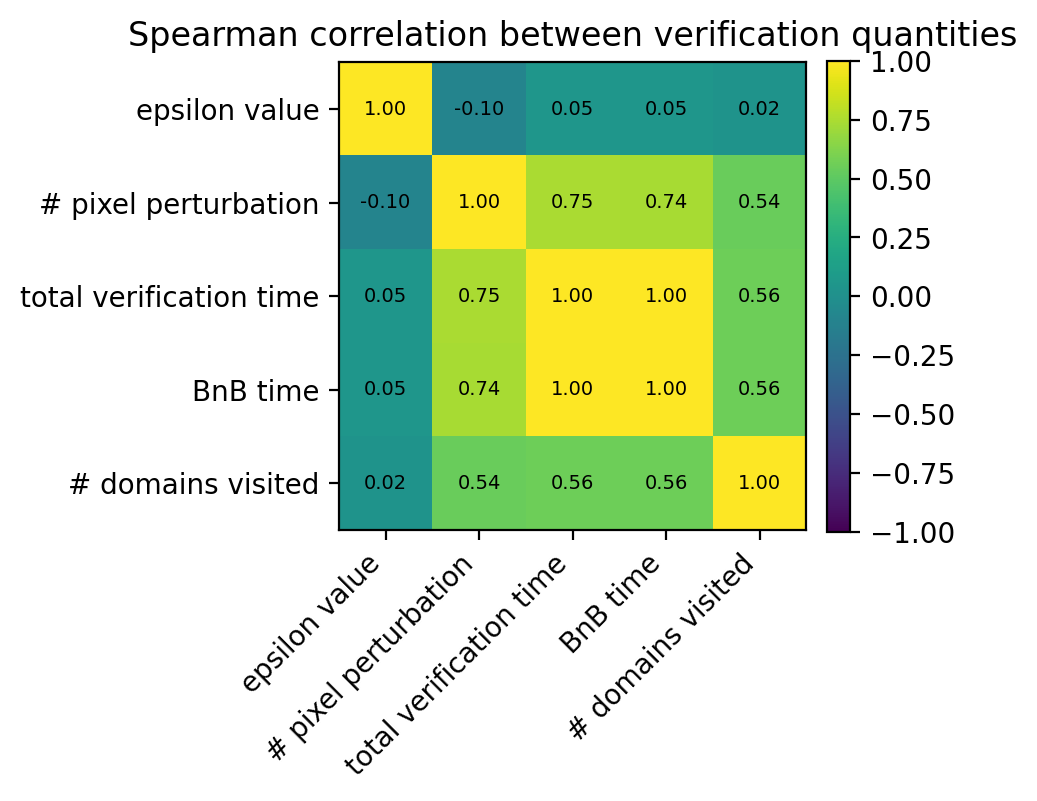

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Select numeric columns
# ---------------------------------------
candidate_cols = [
    "eps",
    "percent_changed",
    "all_time",
    "bab_time",
    "domains_visited",
]

num_cols = [c for c in candidate_cols if c in df.columns]

# Convert to numeric safely
d = df[num_cols].apply(pd.to_numeric, errors="coerce")
d = d.dropna(how="any")

# ---------------------------------------
# Compute correlation (Spearman)
# ---------------------------------------
corr = d.corr(method="spearman")

# ---------------------------------------
# Pretty labels (DISPLAY ONLY)
# ---------------------------------------
LABEL_MAP = {
    "eps": "epsilon value",
    "percent_changed": "# pixel perturbation",
    "all_time": "total verification time",
    "bab_time": "BnB time",
    "domains_visited": "# domains visited",
}

corr = corr.rename(index=LABEL_MAP, columns=LABEL_MAP)

# ---------------------------------------
# Plot correlation heatmap
# ---------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=200)

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

# ✅ title WITHOUT "percentage change only"
ax.set_title("Spearman correlation between verification quantities")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Verification cost correlates with perturbation size and search effort, not with ε.